In [2]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

In [18]:
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_fscore_support

In [5]:
# --- 1. DATA PREPARATION ---
data = load_iris()

X_raw = torch.tensor(data.data, dtype=torch.float32)
Y_raw = torch.tensor(data.target, dtype=torch.long)
print(X_raw.shape, Y_raw.shape)
print(np.unique(Y_raw))

X_train, X_test, Y_train, Y_test = train_test_split(X_raw, Y_raw, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)
print(X_train.shape, Y_train.shape)
print(X_train.shape, X_val.shape, X_test.shape)

scalar = StandardScaler()
X_train = torch.tensor(scalar.fit_transform(X_train), dtype=torch.float32)
X_val = torch.tensor(scalar.transform(X_val), dtype=torch.float32)
X_test = torch.tensor(scalar.transform(X_test), dtype=torch.float32)




torch.Size([150, 4]) torch.Size([150])
[0 1 2]
torch.Size([108, 4]) torch.Size([108])
torch.Size([108, 4]) torch.Size([12, 4]) torch.Size([30, 4])


In [6]:
# --- 2. CREATE PYTORCH DATASETS & DATALOADERS ---
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)




In [7]:
# --- 3. DEFINE THE MLP ---
class simpleMLP(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(simpleMLP, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.output(x)
        return x


In [8]:
# --- 4. TRAINING SETUP ---
model = simpleMLP(input_dim=X_train.shape[1], hidden_dim=4, output_dim=len(np.unique(Y_raw)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

print("training started")

max_epochs = 100
for epoch in range(1, max_epochs+1):
    model.train()
    train_loss = 0
    accuracy = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()

        train_loss = train_loss+loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim=1)
        accuracy = accuracy + (train_pred==batch_Y).sum().item()

    avg_loss = (train_loss/len(train_loader.dataset)) * 100
    avg_acc = (accuracy/len(train_loader.dataset))*100

    #----------------------Validation---------------------#
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)

            val_loss = val_loss+loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim=1)
            val_acc = val_acc + (val_pred==batch_Y).sum().item()
    
        avg_val_loss = (val_loss/len(val_loader.dataset)) * 100
        avg_val_acc = (val_acc/len(val_loader.dataset))*100


    print(f"Epoch {epoch}----> Loss: {avg_loss} & ------> Accuracy: {avg_acc} || Epoch {epoch}----> Loss: {avg_val_loss} & ------> Accuracy: {avg_val_acc}")


training started
Epoch 1----> Loss: 115.0018299067462 & ------> Accuracy: 34.25925925925926 || Epoch 1----> Loss: 116.04422330856323 & ------> Accuracy: 25.0
Epoch 2----> Loss: 113.87612245700977 & ------> Accuracy: 34.25925925925926 || Epoch 2----> Loss: 114.65221643447876 & ------> Accuracy: 25.0
Epoch 3----> Loss: 112.81223164664374 & ------> Accuracy: 34.25925925925926 || Epoch 3----> Loss: 113.37218284606934 & ------> Accuracy: 25.0
Epoch 4----> Loss: 111.75793983318188 & ------> Accuracy: 34.25925925925926 || Epoch 4----> Loss: 112.11344003677368 & ------> Accuracy: 25.0
Epoch 5----> Loss: 110.7687892737212 & ------> Accuracy: 34.25925925925926 || Epoch 5----> Loss: 110.91264486312866 & ------> Accuracy: 25.0
Epoch 6----> Loss: 109.82323929115579 & ------> Accuracy: 34.25925925925926 || Epoch 6----> Loss: 109.75569486618042 & ------> Accuracy: 25.0
Epoch 7----> Loss: 108.88133181465997 & ------> Accuracy: 34.25925925925926 || Epoch 7----> Loss: 108.61026048660278 & ------> Accura

In [9]:
# --- 5. EVALUATION ---

model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        pred = model(batch_X)
        test_pred = pred.argmax(dim=1)
        all_preds.extend(test_pred.cpu().numpy())
        all_targets.extend(batch_Y.cpu().numpy())

target_names = data.target_names
print(classification_report(all_targets, all_preds, target_names=target_names))




              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.00      0.00      0.00         9
   virginica       0.55      1.00      0.71        11

    accuracy                           0.70        30
   macro avg       0.52      0.67      0.57        30
weighted avg       0.54      0.70      0.59        30



/Users/allanyu/RISE Projects/BU-RISE/notebooks/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/allanyu/RISE Projects/BU-RISE/notebooks/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/allanyu/RISE Projects/BU-RISE/notebooks/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [19]:
model = simpleMLP(input_dim=X_train.shape[1], hidden_dim=4, output_dim=len(np.unique(Y_raw)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience=5)

print("training started")
max_epochs = 1000
PATIENCE = 15
patience_counter = 0
best_val_loss = float("inf")
best_mode_weights = None


for epoch in range(1, max_epochs+1):
    model.train()
    train_loss = 0
    accuracy = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()

        train_loss = train_loss+loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim=1)
        accuracy = accuracy + (train_pred==batch_Y).sum().item()

    avg_loss = (train_loss/len(train_loader.dataset)) * 100
    avg_acc = (accuracy/len(train_loader.dataset))*100

    model.eval()
        
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)

            val_loss = val_loss + loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim=1)
            val_acc = val_acc + (val_pred == batch_Y).sum().item()
            

        avg_loss_val = val_loss/len(val_loader.dataset)
        avg_acc_val = val_acc/len(val_loader.dataset)* 100

    scheduler.step(avg_loss_val)
    if avg_loss_val<best_val_loss:
        best_val_loss = avg_loss_val
        best_mode_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter==PATIENCE:
        print("early stop")
        break


    print(f"Epoch {epoch} TrainLosee: {avg_loss} & TrainAccuracy: {avg_acc} || ValLoss: {avg_loss_val} & ValAccuracy: {avg_acc_val}")

training started
Epoch 1 TrainLosee: 120.24732474927549 & TrainAccuracy: 16.666666666666664 || ValLoss: 1.2347074747085571 & ValAccuracy: 8.333333333333332
Epoch 2 TrainLosee: 119.02485026253595 & TrainAccuracy: 17.59259259259259 || ValLoss: 1.2205945253372192 & ValAccuracy: 8.333333333333332
Epoch 3 TrainLosee: 117.94637927302607 & TrainAccuracy: 18.51851851851852 || ValLoss: 1.207524299621582 & ValAccuracy: 8.333333333333332
Epoch 4 TrainLosee: 116.90007050832112 & TrainAccuracy: 20.37037037037037 || ValLoss: 1.1955443620681763 & ValAccuracy: 8.333333333333332
Epoch 5 TrainLosee: 115.93573534930195 & TrainAccuracy: 20.37037037037037 || ValLoss: 1.1843217611312866 & ValAccuracy: 8.333333333333332
Epoch 6 TrainLosee: 115.03620721675732 & TrainAccuracy: 20.37037037037037 || ValLoss: 1.173885464668274 & ValAccuracy: 8.333333333333332
Epoch 7 TrainLosee: 114.12904306694314 & TrainAccuracy: 22.22222222222222 || ValLoss: 1.1641651391983032 & ValAccuracy: 8.333333333333332
Epoch 8 TrainLosee

In [20]:
# --- 5. EVALUATION --- (Copy 5)
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        pred = model(batch_X)
        test_pred = pred.argmax(dim=1)
        all_preds.extend(test_pred.cpu().numpy())
        all_targets.extend(batch_Y.cpu().numpy())

target_names = data.target_names
print(classification_report(all_targets, all_preds, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



[0.16957255 0.1540411  0.26875412 0.16602889]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


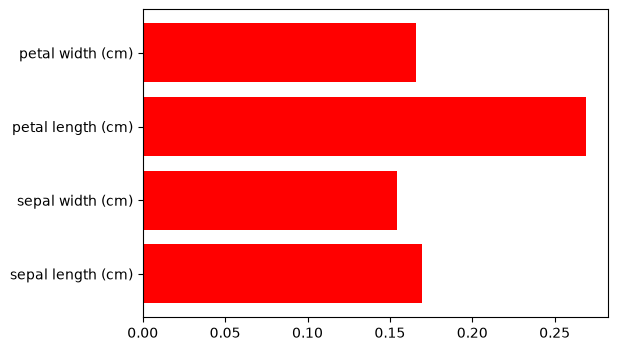

In [29]:
# --- Feature Importance via Input Gradient Analysis ---
import matplotlib.pyplot as plt
X_test_grad = X_test.clone().detach().requires_grad_(True)

output = model(X_test_grad)
output.sum().backward()

importance = X_test_grad.grad.abs().mean(dim=0).numpy()
print(importance)
featuress_names = data.feature_names
print(featuress_names)

plt.figure(figsize=(6,4))
plt.barh(featuress_names, importance, color="red")
plt.show()

In [30]:
# Train on some other standard datasets
from sklearn.datasets import load_wine, load_digits, load_breast_cancer
import numpy as np
# Copy 1, 2, 3, D, 5
data = load_iris()

X_raw = torch.tensor(data.data, dtype=torch.float32)
Y_raw = torch.tensor(data.target, dtype=torch.long)
print(X_raw.shape, Y_raw.shape)
print(np.unique(Y_raw))

X_train, X_test, Y_train, Y_test = train_test_split(X_raw, Y_raw, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)
print(X_train.shape, Y_train.shape)
print(X_train.shape, X_val.shape, X_test.shape)

scalar = StandardScaler()
X_train = torch.tensor(scalar.fit_transform(X_train), dtype=torch.float32)
X_val = torch.tensor(scalar.transform(X_val), dtype=torch.float32)
X_test = torch.tensor(scalar.transform(X_test), dtype=torch.float32)


torch.Size([150, 4]) torch.Size([150])
[0 1 2]
torch.Size([108, 4]) torch.Size([108])
torch.Size([108, 4]) torch.Size([12, 4]) torch.Size([30, 4])


In [31]:
# --- 2. CREATE PYTORCH DATASETS & DATALOADERS ---
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [38]:
# --- 3. DEFINE THE MLP ---
class simpleMLP(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(simpleMLP, self).__init__()
        self.hidden1 = nn.Linear(input_dim, hidden_dim)
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.relu1(self.hidden1(x))
        x = self.relu2(self.hidden2(x))
        x = self.output(x)
        return x

In [40]:
model = simpleMLP(input_dim=X_train.shape[1], hidden_dim=4, output_dim=len(np.unique(Y_raw)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience=5)

print("training started")
max_epochs = 1000
PATIENCE = 15
patience_counter = 0
best_val_loss = float("inf")
best_mode_weights = None


for epoch in range(1, max_epochs+1):
    model.train()
    train_loss = 0
    accuracy = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()

        train_loss = train_loss+loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim=1)
        accuracy = accuracy + (train_pred==batch_Y).sum().item()

    avg_loss = (train_loss/len(train_loader.dataset)) * 100
    avg_acc = (accuracy/len(train_loader.dataset))*100

    model.eval()
        
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)

            val_loss = val_loss + loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim=1)
            val_acc = val_acc + (val_pred == batch_Y).sum().item()
            

        avg_loss_val = val_loss/len(val_loader.dataset)
        avg_acc_val = val_acc/len(val_loader.dataset)* 100

    scheduler.step(avg_loss_val)
    if avg_loss_val<best_val_loss:
        best_val_loss = avg_loss_val
        best_mode_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter==PATIENCE:
        print("early stop")
        break


    print(f"Epoch {epoch} TrainLosee: {avg_loss} & TrainAccuracy: {avg_acc} || ValLoss: {avg_loss_val} & ValAccuracy: {avg_acc_val}")

training started
Epoch 1 TrainLosee: 109.53090146735862 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.0599960088729858 & ValAccuracy: 41.66666666666667
Epoch 2 TrainLosee: 109.08879968855116 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.057511806488037 & ValAccuracy: 41.66666666666667
Epoch 3 TrainLosee: 108.65189984992698 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.0551058053970337 & ValAccuracy: 41.66666666666667
Epoch 4 TrainLosee: 108.24027282220345 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.0526703596115112 & ValAccuracy: 41.66666666666667
Epoch 5 TrainLosee: 107.85058383588438 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.0501068830490112 & ValAccuracy: 41.66666666666667
Epoch 6 TrainLosee: 107.42708864035431 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.0474307537078857 & ValAccuracy: 41.66666666666667
Epoch 7 TrainLosee: 107.02694654464722 & TrainAccuracy: 33.33333333333333 || ValLoss: 1.044625997543335 & ValAccuracy: 41.66666666666667
Epoch 8 TrainLosee: